# Tâche 2 — Estimation du Revenu à Risque (Régression)

Cette tâche complémentaire répond à une question business concrète :
*Combien l'entreprise risque-t-elle de perdre si un client churne ?*

**Variable cible :** `revenue_at_risk = total_revenue × probabilité_de_churn`

La probabilité de churn est celle prédite par le meilleur modèle de classification
(chargé depuis les fichiers locaux). Cette approche permet de construire une variable
cible plus réaliste que d'utiliser le churn binaire comme proxy.

**Modèles testés :** Ridge, Random Forest Regressor, XGBoost Regressor, MLP Regressor

In [7]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from xgboost import XGBRegressor

from src.data.loader import PROCESSED_DIR, load_raw, make_train_test_split, TARGET_REGRESSION
from src.data.preprocessor import add_revenue_at_risk, add_engagement_score
from src.evaluation.metrics import compute_regression_metrics, plot_regression_scatter
from src.models.mlflow_utils import setup_mlflow, log_regression_run, EXPERIMENT_REVENUE

plt.rcParams['figure.dpi'] = 110

X_train = pd.read_csv(PROCESSED_DIR / 'X_train_regression.csv')
X_test = pd.read_csv(PROCESSED_DIR / 'X_test_regression.csv')
y_train = pd.read_csv(PROCESSED_DIR / 'y_train_regression.csv').squeeze()
y_test = pd.read_csv(PROCESSED_DIR / 'y_test_regression.csv').squeeze()

print(f"Train : {X_train.shape} | Test : {X_test.shape}")
print(f"\nDistribution revenue_at_risk (test) :")
print(y_test.describe().round(2))

Train : (8000, 58) | Test : (2000, 58)

Distribution revenue_at_risk (test) :
count    2000.00
mean      109.91
std       104.12
min         1.00
25%        36.00
50%        78.00
75%       150.00
max       590.00
Name: revenue_at_risk, dtype: float64


## 1. Recalcul de revenue_at_risk avec les vraies probabilités de churn

In [8]:
# On charge le meilleur modèle de classification disponible localement
# pour recalculer une variable cible plus précise que le proxy 10%.
# Si XGBoost est disponible, on le préfère car généralement le plus performant.
import os

df_raw = load_raw()
df = add_engagement_score(df_raw)

model_path = PROCESSED_DIR / 'model_xgboost.joblib'
if not model_path.exists():
    model_path = PROCESSED_DIR / 'model_random_forest.joblib'
if not model_path.exists():
    model_path = PROCESSED_DIR / 'model_logistic_regression.joblib'

if model_path.exists():
    clf = joblib.load(model_path)
    preprocessor = joblib.load(PROCESSED_DIR / 'preprocessing_pipeline.joblib')
    
    from src.data.loader import split_features_target
    X_all, y_all = split_features_target(df, 'churn')
    X_processed = preprocessor.transform(X_all)
    churn_proba = clf.predict_proba(X_processed)[:, 1]
    
    df = add_revenue_at_risk(df, churn_proba=churn_proba)
    print(f"Variable cible recalculée avec {model_path.name}")
    print(f"revenue_at_risk moyen : {df['revenue_at_risk'].mean():.2f} €")
else:
    print("Aucun modèle de classification trouvé — on utilise le proxy 10%.")
    df = add_revenue_at_risk(df)

Dataset chargé : 10,000 lignes, 32 colonnes
Variable cible recalculée avec model_xgboost.joblib
revenue_at_risk moyen : 113.20 €


## 2. Entraînement et évaluation des 4 modèles de régression

In [9]:
models = {
    'Ridge': Ridge(alpha=1.0),
    'Random Forest Regressor': RandomForestRegressor(
        n_estimators=200, max_depth=12, random_state=42, n_jobs=-1
    ),
    'XGBoost Regressor': XGBRegressor(
        n_estimators=300, learning_rate=0.1, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        random_state=42, verbosity=0, n_jobs=-1
    ),
    'MLP Regressor': MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=300,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
    ),
}

results = {}
setup_mlflow(EXPERIMENT_REVENUE)

for name, reg_model in models.items():
    print(f"\nEntraînement : {name}")
    reg_model.fit(X_train, y_train)
    y_pred = reg_model.predict(X_test)
    metrics = compute_regression_metrics(y_test.values, y_pred)
    results[name] = {'metrics': metrics, 'model': reg_model, 'y_pred': y_pred}
    
    print(f"  RMSE : {metrics['rmse']:.2f} | MAE : {metrics['mae']:.2f} | R² : {metrics['r2']:.4f}")
    
    # Logging MLflow
    params = reg_model.get_params()
    params = {k: str(v) for k, v in params.items() if v is not None}
    log_regression_run(
        model=reg_model, model_name=name, params=params,
        metrics=metrics, X_train=X_train, X_test=X_test, y_test=y_test
    )

Expérience MLflow : 'revenue_at_risk_regression' (id=3)

Entraînement : Ridge
  RMSE : 0.03 | MAE : 0.02 | R² : 1.0000
Run enregistré : Ridge | run_id=9b2ba4200a974a9081a87ed53cc141f2
  RMSE : 0.0318
  R²   : 1.0000
🏃 View run Ridge at: http://localhost:5000/#/experiments/3/runs/9b2ba4200a974a9081a87ed53cc141f2
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entraînement : Random Forest Regressor
  RMSE : 0.08 | MAE : 0.01 | R² : 1.0000
Run enregistré : Random Forest Regressor | run_id=e84356a1848a415181632ee9f1bb55be
  RMSE : 0.0782
  R²   : 1.0000
🏃 View run Random Forest Regressor at: http://localhost:5000/#/experiments/3/runs/e84356a1848a415181632ee9f1bb55be
🧪 View experiment at: http://localhost:5000/#/experiments/3

Entraînement : XGBoost Regressor
  RMSE : 0.65 | MAE : 0.39 | R² : 1.0000
Run enregistré : XGBoost Regressor | run_id=9301019dbf6f4999999252106ac90d03
  RMSE : 0.6516
  R²   : 1.0000
🏃 View run XGBoost Regressor at: http://localhost:5000/#/experiments/3/r

## 3. Comparaison des modèles de régression

In [10]:
comparison_df = pd.DataFrame({
    name: res['metrics'] for name, res in results.items()
}).T.round(4)
display(comparison_df.sort_values('rmse'))

,mae,rmse,r2
Ridge,0.0227,0.0318,1.0000
Random Forest Regressor,0.0097,0.0782,1.0000
XGBoost Regressor,0.3898,0.6516,1.0000
MLP Regressor,1.5655,1.9936,0.9996


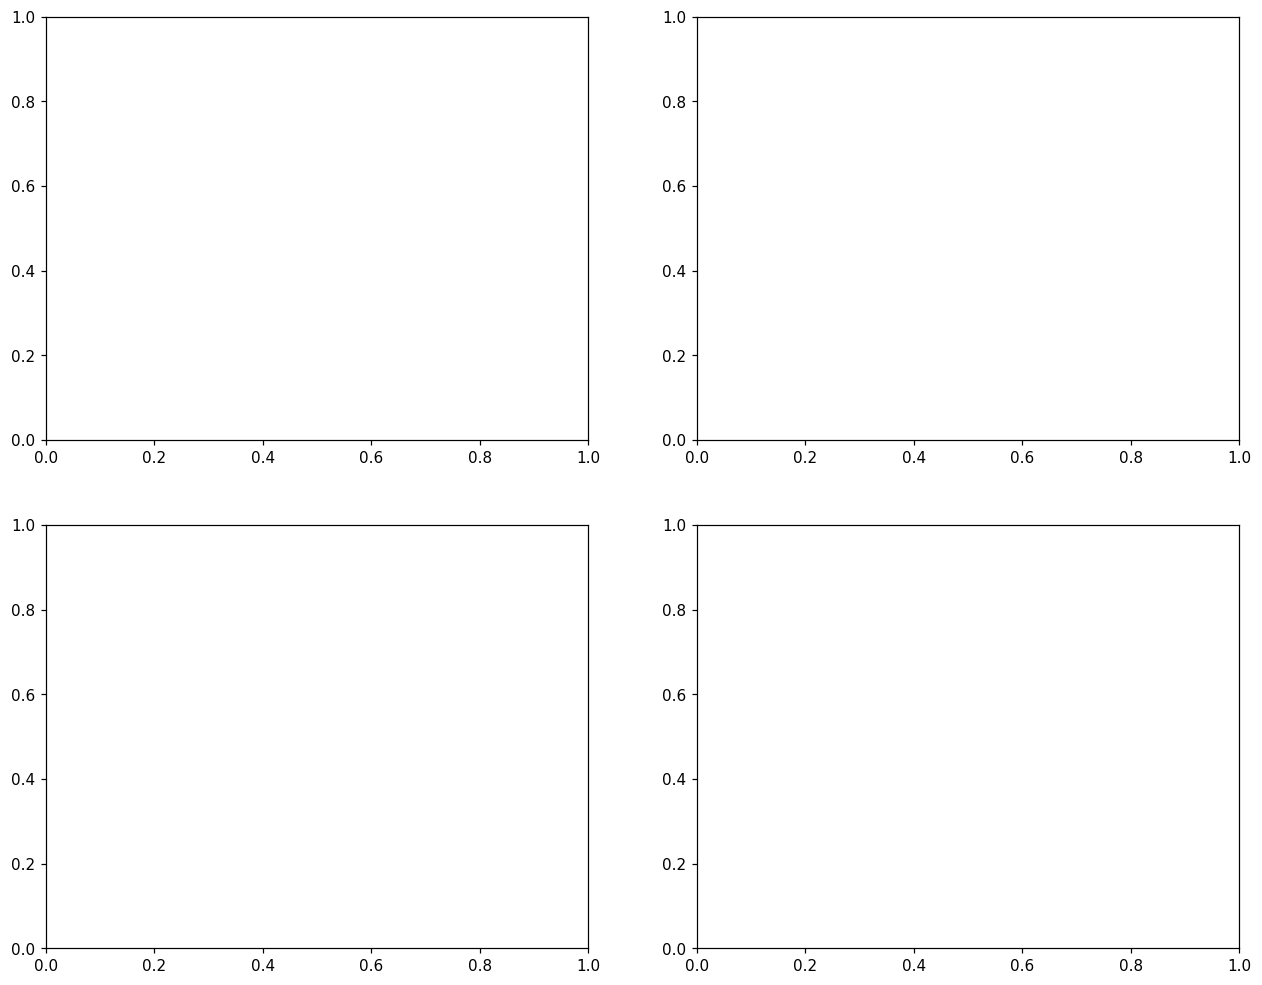

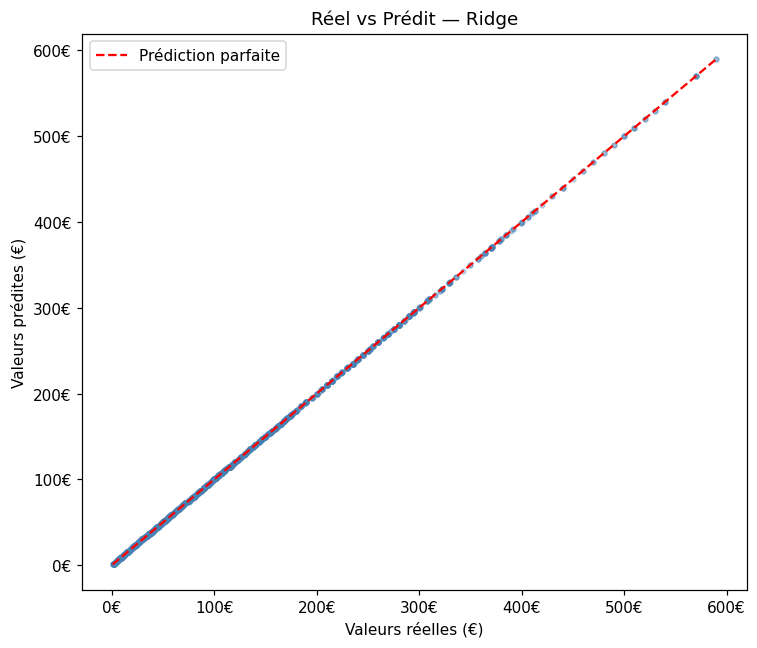

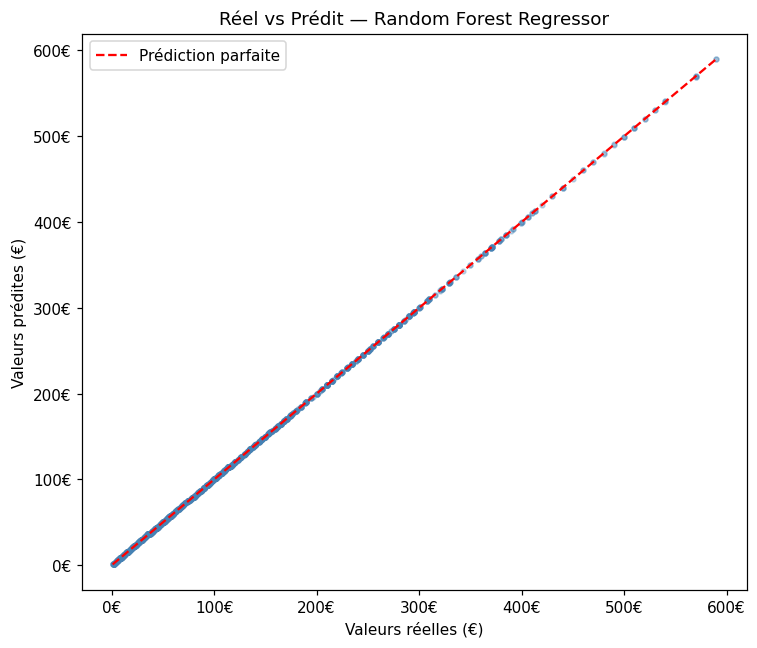

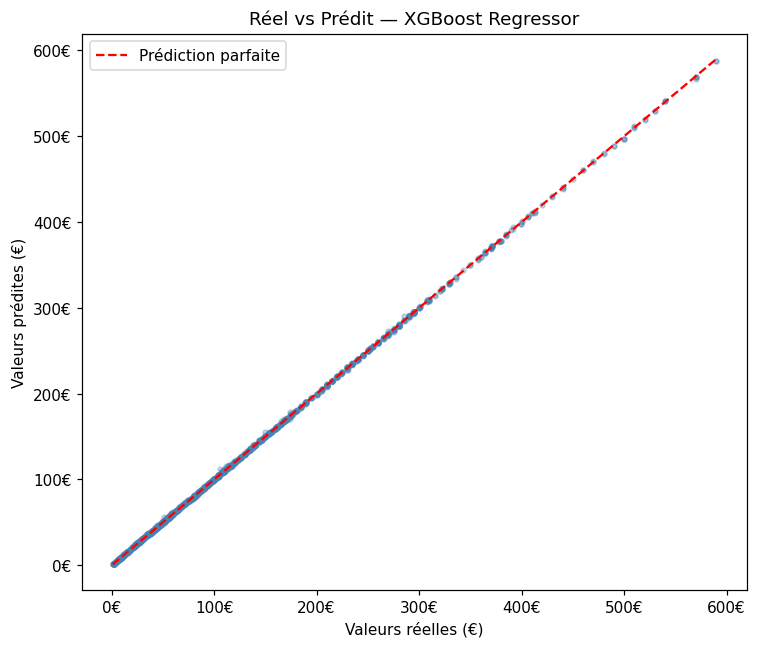

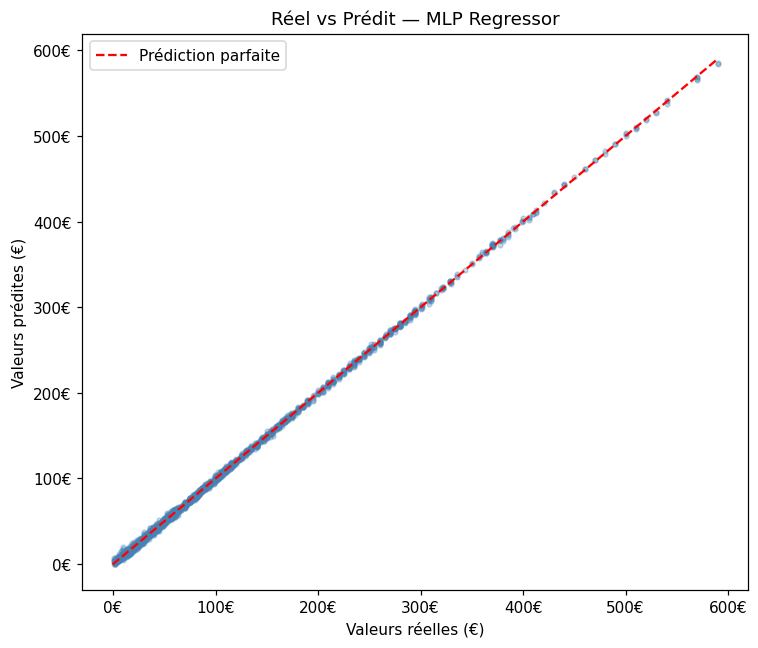

In [11]:
# Nuages de points réel vs prédit pour chaque modèle
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    plot_regression_scatter(y_test.values, res['y_pred'], name)
    
plt.tight_layout()
plt.savefig('../data/processed/fig_regression_scatter.png', bbox_inches='tight')
plt.show()

In [12]:
# Sauvegarde du meilleur modèle de régression
best_name = comparison_df['rmse'].idxmin()
best_reg_model = results[best_name]['model']
joblib.dump(best_reg_model, PROCESSED_DIR / 'model_best_regressor.joblib')
print(f"Meilleur modèle de régression : {best_name}")
print(f"RMSE : {results[best_name]['metrics']['rmse']:.2f} €")

Meilleur modèle de régression : Ridge
RMSE : 0.03 €
